# KLASIFIKASI PERFORMA AKADEMIK MAHASISWA
## Algoritma Decision Tree & Naive Bayes — From Scratch

**Dataset:** student_habits_performance.csv  
**Jumlah Data:** 1000 baris, 16 kolom  



## 1. Import Library (Hanya Untuk Data & Visualisasi)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Tidak menggunakan sklearn sama sekali!
# Decision Tree dan Naive Bayes dibuat dari nol.

plt.style.use('ggplot')
print("Library berhasil di-import!")

Library berhasil di-import!


## 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/student_habits_performance.csv', sep=';', decimal=',')
df.head(10)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
6,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Master,Poor,4,No,89.8
7,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Bachelor,Average,8,No,72.6
8,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Bachelor,Good,1,No,78.9
9,S1009,18,Female,4.8,3.1,1.3,No,95.4,7.5,Good,5,Bachelor,Good,10,Yes,100.0


## 3. Exploratory Data Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [ ]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [ ]:
# Cek missing value
print("Missing value per kolom:")
print(df.isnull().sum())

Missing value per kolom:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [ ]:
# Isi missing value dengan modus (nilai yang paling sering muncul)
df['parental_education_level'] = df['parental_education_level'].fillna(
    df['parental_education_level'].mode()[0]
)

print("Setelah penanganan missing value:")
print(df.isnull().sum())

Setelah penanganan missing value:
student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64


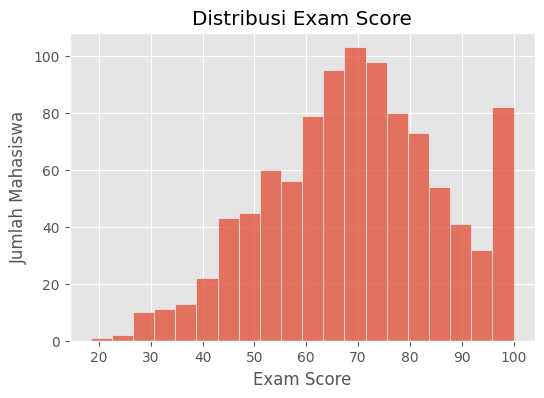

In [ ]:
# Distribusi Exam Score
plt.figure(figsize=(6, 4))
sns.histplot(df['exam_score'], bins=20)
plt.title("Distribusi Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

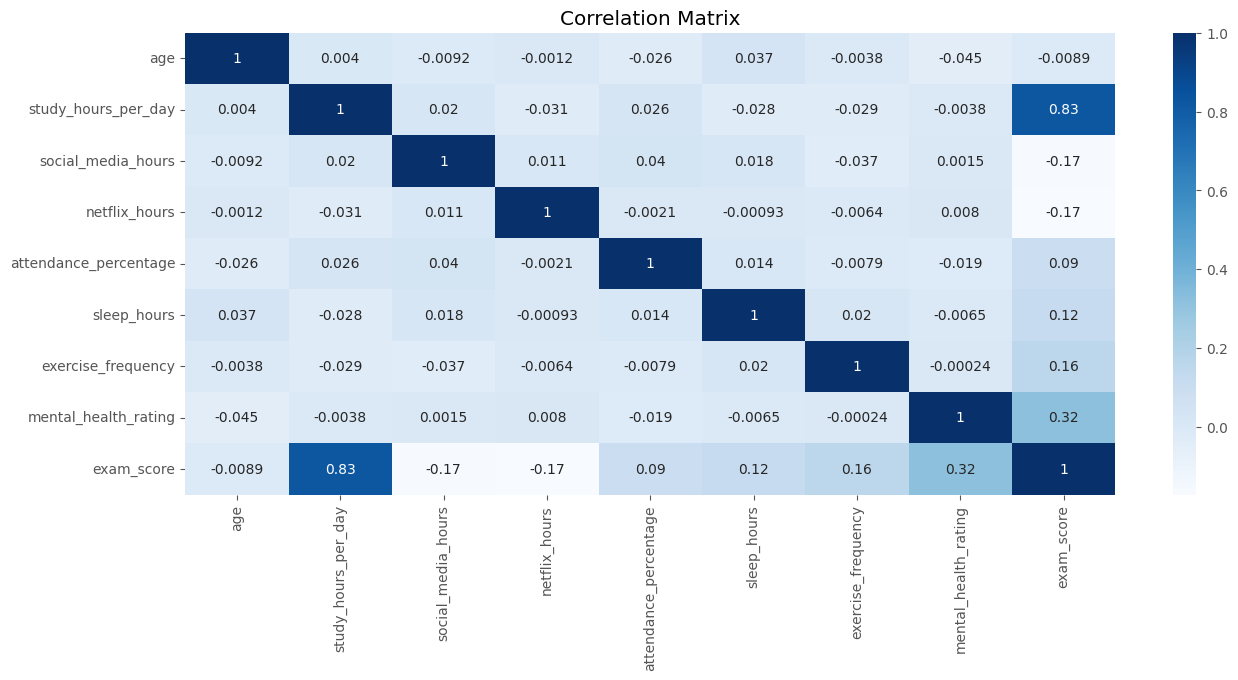

In [ ]:
# Heatmap Korelasi
plt.figure(figsize=(15, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

## 4. Preprocessing — Label Encoding (From Scratch)

Kolom bertipe teks (kategorikal) perlu diubah ke angka agar bisa diproses oleh algoritma.

**Cara kerja Label Encoding:**  
Setiap nilai unik pada kolom diberi nomor urut 0, 1, 2, dst.

In [ ]:
def label_encode(series):
    """
    Mengubah kolom kategorikal menjadi angka.
    Contoh: ['Laki', 'Perempuan', 'Laki'] -> [0, 1, 0]
    """
    unique_values = sorted(series.dropna().unique())  # urutkan nilai unik
    mapping = {val: idx for idx, val in enumerate(unique_values)}  # buat peta nilai -> angka
    return series.map(mapping), mapping


# Kolom yang perlu di-encode
categorical_cols = [
    'gender',
    'part_time_job',
    'diet_quality',
    'parental_education_level',
    'internet_quality',
    'extracurricular_participation'
]

encodings = {}  # simpan mapping untuk referensi
for col in categorical_cols:
    df[col], encodings[col] = label_encode(df[col])
    print(f"{col}: {encodings[col]}")

gender: {'Female': 0, 'Male': 1, 'Other': 2}
part_time_job: {'No': 0, 'Yes': 1}
diet_quality: {'Fair': 0, 'Good': 1, 'Poor': 2}
parental_education_level: {'Bachelor': 0, 'High School': 1, 'Master': 2}
internet_quality: {'Average': 0, 'Good': 1, 'Poor': 2}
extracurricular_participation: {'No': 0, 'Yes': 1}


## 5. Membuat Label Performa Akademik

Kita buat kategori berdasarkan nilai `exam_score`:
- **Tinggi** → skor ≥ 70
- **Sedang** → 50 ≤ skor < 70
- **Rendah** → skor < 50

In [ ]:
def kategori(score):
    if score >= 70:
        return 'Tinggi'
    elif score >= 50:
        return 'Sedang'
    else:
        return 'Rendah'

df['performance'] = df['exam_score'].apply(kategori)

print("Distribusi kelas:")
print(df['performance'].value_counts())

df[['student_id', 'study_hours_per_day', 'attendance_percentage', 'exam_score', 'performance']].head(10)

Distribusi kelas:
performance
Tinggi    511
Sedang    358
Rendah    131
Name: count, dtype: int64


,student_id,study_hours_per_day,attendance_percentage,exam_score,performance
0,S1000,0.0,85.0,56.2,Sedang
1,S1001,6.9,97.3,100.0,Tinggi
2,S1002,1.4,94.8,34.3,Rendah
3,S1003,1.0,71.0,26.8,Rendah
4,S1004,5.0,90.9,66.4,Sedang
5,S1005,7.2,82.9,100.0,Tinggi
6,S1006,5.6,85.8,89.8,Tinggi
7,S1007,4.3,77.7,72.6,Tinggi
8,S1008,4.4,100.0,78.9,Tinggi
9,S1009,4.8,95.4,100.0,Tinggi


In [ ]:
# Menentukan fitur (X) dan target (y)

X = df.drop(columns=['student_id', 'exam_score', 'performance'])
y = df['performance']

feature_names = list(X.columns)

print("Jumlah fitur:", len(feature_names))
print(feature_names)

Jumlah fitur: 14
['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']


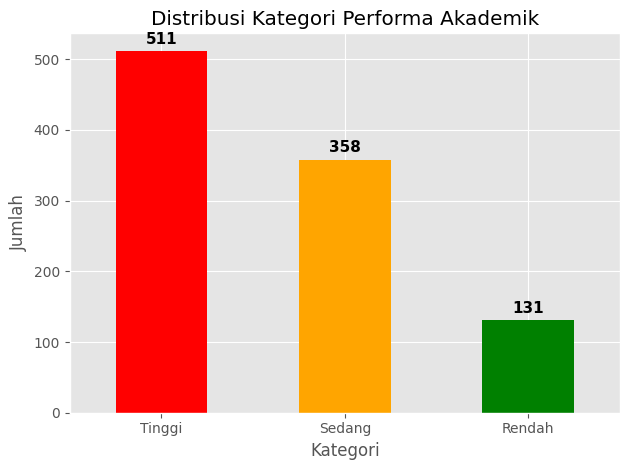

In [ ]:
ax = df['performance'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'])
plt.title("Distribusi Kategori Performa Akademik")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fontsize=11, fontweight='bold', padding=3)

plt.tight_layout()
plt.show()

## 6. Menentukan Fitur & Split Data (From Scratch)

**Train-test split** memisahkan data menjadi:
- **80% Training** → dipakai untuk melatih model
- **20% Testing** → dipakai untuk menguji hasil prediksi

Parameter `stratify` memastikan proporsi kelas di training dan testing sama.

In [ ]:
import numpy as np

def train_test_split_scratch(X, y, test_size=0.2, random_state=42):

    np.random.seed(random_state)

    # Ubah ke numpy array
    X = np.array(X)
    y = np.array(y)

    train_idx = []
    test_idx = []

    # Ambil setiap kelas
    classes = np.unique(y)

    for cls in classes:

        # Indeks data pada kelas tersebut
        idx = np.where(y == cls)[0]

        # Acak indeks
        np.random.shuffle(idx)

        # Tentukan jumlah data testing
        n_test = int(np.round(len(idx) * test_size))

        # Pisahkan train dan test
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])

    # Acak kembali urutan data
    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)

    return (
        X[train_idx],
        X[test_idx],
        y[train_idx],
        y[test_idx]
    )


# ===========================
# Split Data
# ===========================

X_train, X_test, y_train, y_test = train_test_split_scratch(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Jumlah Data Training :", len(X_train))
print("Jumlah Data Testing  :", len(X_test))

Jumlah Data Training : 800
Jumlah Data Testing  : 200


## 7. Decision Tree — From Scratch

**Cara kerja Decision Tree:**
1. Pilih fitur terbaik untuk membagi data (berdasarkan **Gini Impurity** terendah)
2. Bagi data menjadi cabang-cabang berdasarkan nilai fitur tersebut
3. Ulangi sampai mencapai batas kedalaman atau data sudah murni satu kelas

**Gini Impurity** mengukur seberapa "kotor" (campur aduk) suatu node:  
`Gini = 1 - Σ p²` dimana p = proporsi tiap kelas

In [ ]:
from collections import Counter

def gini_impurity(y):
    """
    Menghitung Gini Impurity untuk mengukur kemurnian kelas.
    Gini = 0 -> semua data satu kelas (murni)
    Gini mendekati 1 -> data tercampur banyak kelas
    """
    n = len(y)
    if n == 0:
        return 0
    counts = Counter(y)
    return 1 - sum((c/n)**2 for c in counts.values())

In [ ]:
def best_split(X, y):
    n, n_features = X.shape
    best_gini = float('inf')
    best_feature, best_threshold = None, None

    for feature_idx in range(n_features):
        thresholds = np.unique(X[:, feature_idx])
        for threshold in thresholds:
            left_mask  = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gini_left  = gini_impurity(y[left_mask])
            gini_right = gini_impurity(y[right_mask])
            weighted_gini = (left_mask.sum() * gini_left + right_mask.sum() * gini_right) / n
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature_idx
                best_threshold = threshold
    return best_feature, best_threshold, best_gini


def build_tree(X, y, depth=0, max_depth=4):
    classes = ['Rendah', 'Sedang', 'Tinggi']
    counts  = Counter(y)
    value   = [counts.get(c, 0) for c in classes]

    if depth >= max_depth or len(set(y)) == 1:
        return {
            'leaf'   : True,
            'label'  : Counter(y).most_common(1)[0][0],
            'samples': len(y),
            'gini'   : round(gini_impurity(y), 3),
            'value'  : value
        }

    feature_idx, threshold, best_gini = best_split(X, y)

    if feature_idx is None:
        return {
            'leaf'   : True,
            'label'  : Counter(y).most_common(1)[0][0],
            'samples': len(y),
            'gini'   : round(gini_impurity(y), 3),
            'value'  : value
        }

    left_mask  = X[:, feature_idx] <= threshold
    right_mask = ~left_mask

    return {
        'leaf'     : False,
        'feature'  : feature_idx,
        'threshold': threshold,
        'gini'     : round(best_gini, 3),
        'samples'  : len(y),
        'value'    : value,
        'left'     : build_tree(X[left_mask],  y[left_mask],  depth + 1, max_depth),
        'right'    : build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)
    }


def predict_tree(node, x):
    if node['leaf']:
        return node['label']
    if x[node['feature']] <= node['threshold']:
        return predict_tree(node['left'], x)
    else:
        return predict_tree(node['right'], x)


print("Melatih Decision Tree... (mohon tunggu)")
dt_tree = build_tree(X_train, y_train, max_depth=4)
y_pred_dt = np.array([predict_tree(dt_tree, x) for x in X_test])
print("Selesai!")
print(dt_tree.keys())

Melatih Decision Tree... (mohon tunggu)
Selesai!
dict_keys(['leaf', 'feature', 'threshold', 'gini', 'samples', 'value', 'left', 'right'])


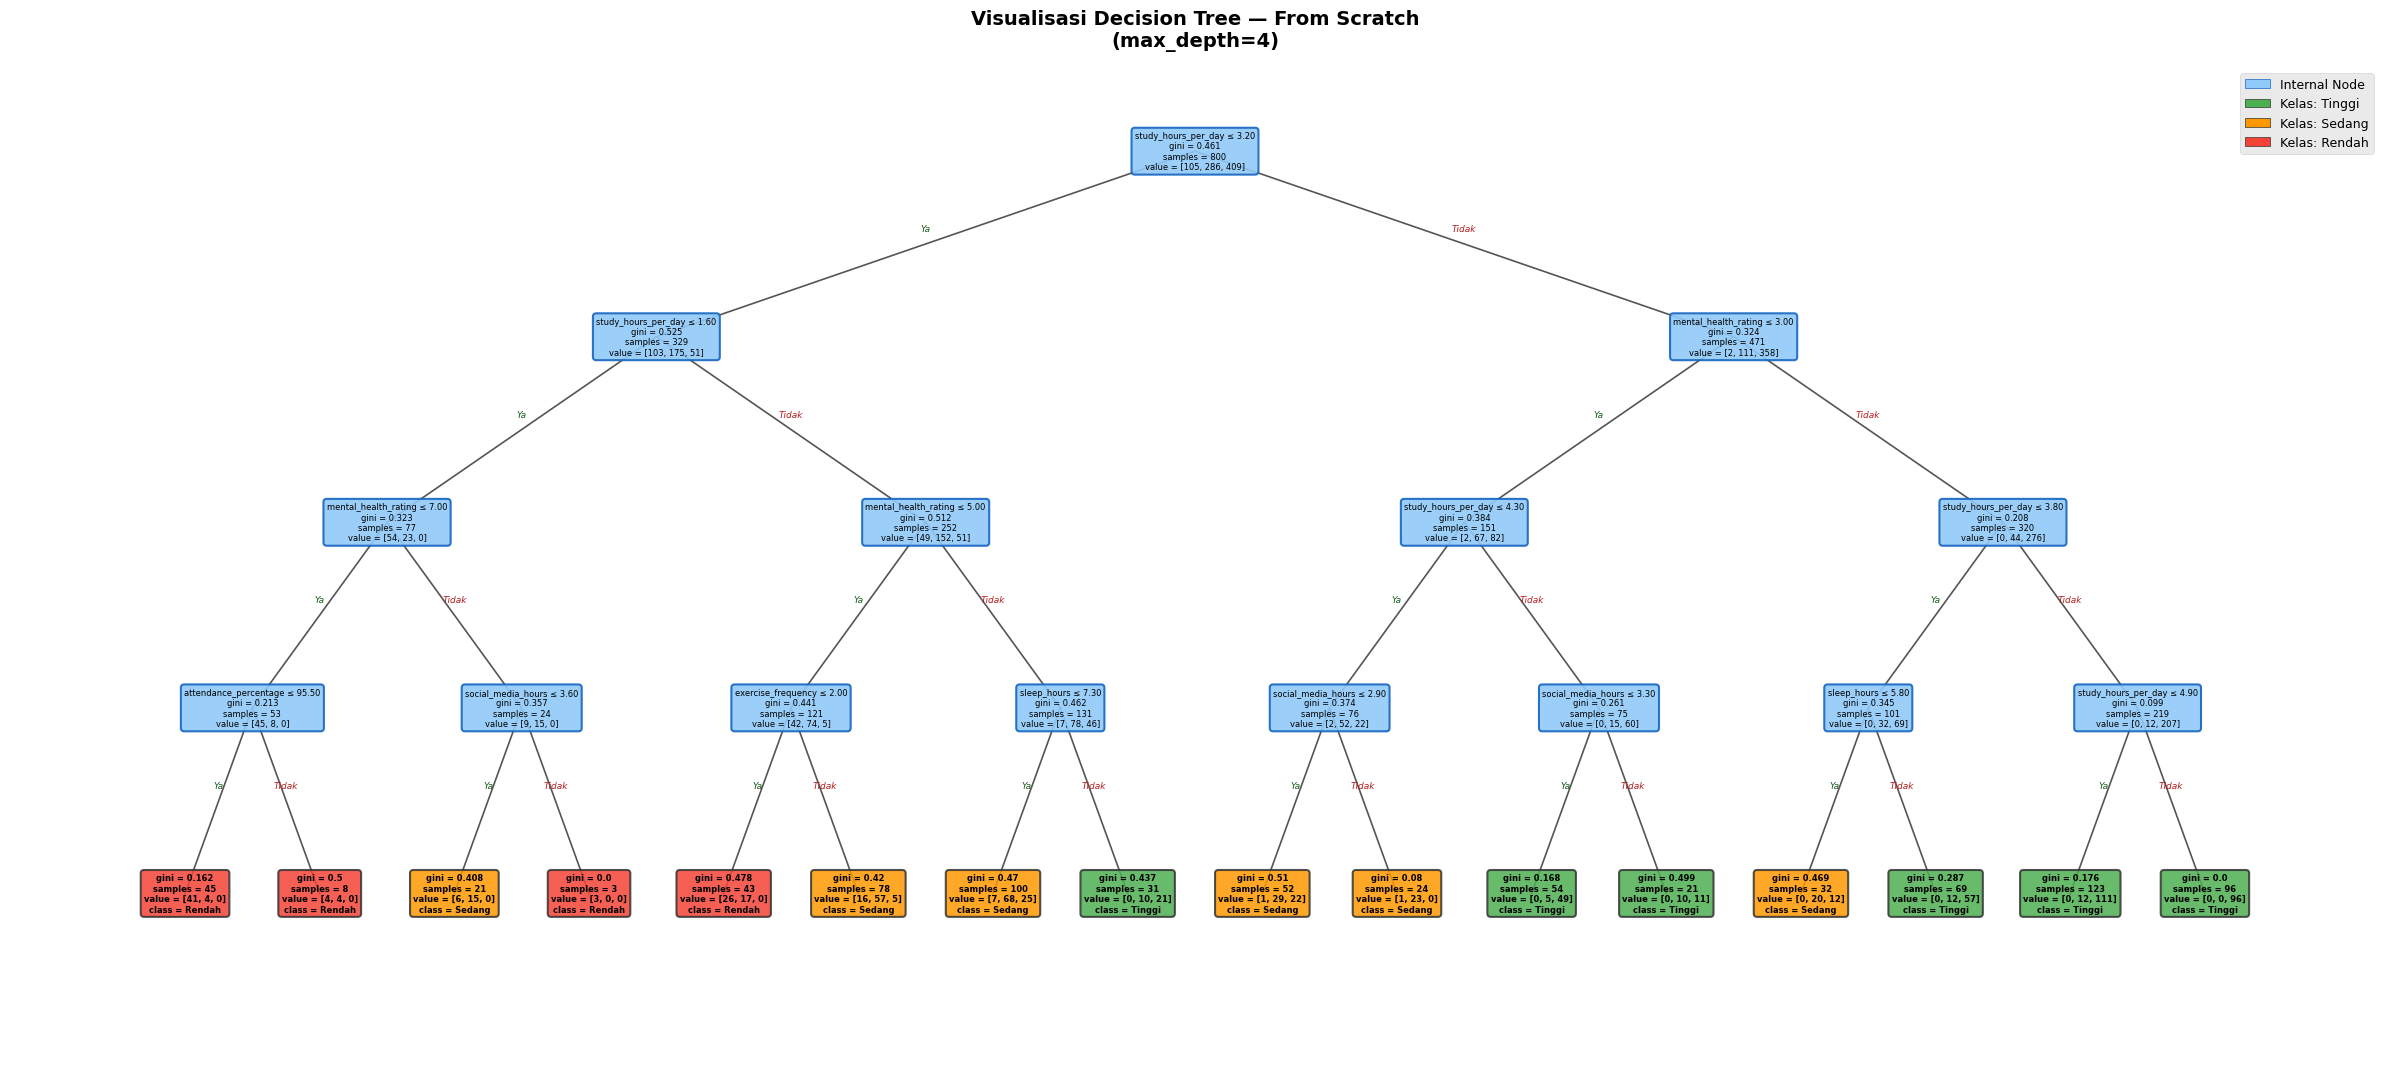

In [ ]:
# ============================================================
# VISUALISASI DECISION TREE — FROM SCRATCH
# ============================================================

from matplotlib.patches import Patch

def draw_tree(ax, node, x, y, dx, dy, feature_names, depth=0, parent_xy=None):
    leaf_colors = {
        'Tinggi': '#4caf50',
        'Sedang': '#ff9800',
        'Rendah': '#f44336',
    }

    if node['leaf']:
        color = leaf_colors.get(node['label'], '#ffffff')
        text  = (f"gini = {node['gini']}\n"
                 f"samples = {node['samples']}\n"
                 f"value = {node['value']}\n"
                 f"class = {node['label']}")
        style = dict(boxstyle='round,pad=0.4', facecolor=color,
                     edgecolor='#333333', linewidth=1.5, alpha=0.85)
        ax.text(x, y, text, ha='center', va='center',
                fontsize=6, fontweight='bold', bbox=style)
    else:
        fname = feature_names[node['feature']]
        text  = (f"{fname} ≤ {node['threshold']:.2f}\n"
                 f"gini = {node['gini']}\n"
                 f"samples = {node['samples']}\n"
                 f"value = {node['value']}")
        style = dict(boxstyle='round,pad=0.4', facecolor='#90caf9',
                     edgecolor='#1565c0', linewidth=1.5, alpha=0.9)
        ax.text(x, y, text, ha='center', va='center',
                fontsize=6, bbox=style)

    if parent_xy is not None:
        ax.plot([parent_xy[0], x], [parent_xy[1], y],
                color='#555555', linewidth=1.2, zorder=0)

    if not node['leaf']:
        child_y = y - dy
        left_x  = x - dx
        right_x = x + dx

        ax.text((x + left_x)  / 2, (y + child_y) / 2 + 0.015,
                'Ya',    fontsize=6.5, color='#1b5e20', ha='center', fontstyle='italic')
        ax.text((x + right_x) / 2, (y + child_y) / 2 + 0.015,
                'Tidak', fontsize=6.5, color='#b71c1c', ha='center', fontstyle='italic')

        draw_tree(ax, node['left'],  left_x,  child_y, dx/2, dy, feature_names, depth+1, (x, y))
        draw_tree(ax, node['right'], right_x, child_y, dx/2, dy, feature_names, depth+1, (x, y))


fig, ax = plt.subplots(figsize=(24, 11))
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.axis('off')
ax.set_title('Visualisasi Decision Tree — From Scratch\n(max_depth=4)',
             fontsize=14, fontweight='bold', pad=15)

legend_elements = [
    Patch(facecolor='#90caf9', edgecolor='#1565c0', label='Internal Node'),
    Patch(facecolor='#4caf50', edgecolor='#333',    label='Kelas: Tinggi'),
    Patch(facecolor='#ff9800', edgecolor='#333',    label='Kelas: Sedang'),
    Patch(facecolor='#f44336', edgecolor='#333',    label='Kelas: Rendah'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.8)

draw_tree(ax, dt_tree, x=0, y=1.0, dx=0.5, dy=0.22, feature_names=feature_names)

plt.tight_layout()
plt.show()

## 8. Naive Bayes (Gaussian) — From Scratch

**Cara kerja Naive Bayes:**
1. Hitung probabilitas setiap kelas → P(kelas)
2. Untuk setiap fitur numerik, hitung rata-rata dan standar deviasi per kelas
3. Gunakan **Gaussian PDF** untuk menghitung P(fitur | kelas)
4. Kelas dengan P(kelas) × Π P(fitur | kelas) terbesar = hasil prediksi

**Gaussian PDF:**  
`P(x | μ, σ) = (1 / √(2πσ²)) × exp(-(x-μ)² / 2σ²)`

In [ ]:
# ============================================================
# NAIVE BAYES (GAUSSIAN) FROM SCRATCH
# ============================================================

class GaussianNaiveBayes:
    """
    Gaussian Naive Bayes:
    Mengasumsikan setiap fitur mengikuti distribusi normal (Gaussian).
    """

    def fit(self, X, y):
        """
        Fase training: hitung rata-rata, variansi, dan prior probability tiap kelas.
        """
        self.classes = np.unique(y)
        self.mean  = {}  # rata-rata tiap fitur per kelas
        self.var   = {}  # variansi tiap fitur per kelas
        self.prior = {}  # P(kelas) = proporsi kelas di data training

        for cls in self.classes:
            X_cls = X[y == cls]
            self.mean[cls]  = X_cls.mean(axis=0)              # rata-rata per fitur
            self.var[cls]   = X_cls.var(axis=0) + 1e-9        # variansi (+ epsilon agar tidak 0)
            self.prior[cls] = len(X_cls) / len(X)             # P(kelas)

    def _gaussian_pdf(self, x, mean, var):
        """
        Menghitung probabilitas x berdasarkan distribusi Gaussian.
        Rumus: (1 / sqrt(2π·var)) × exp(-(x - mean)² / 2·var)
        """
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mean) ** 2) / (2 * var))

    def predict_proba(self, X):
        """
        Menghitung probabilitas setiap kelas untuk setiap data.
        Menggunakan log probability agar tidak underflow (nilai jadi terlalu kecil).
        """
        log_probs = []
        for x in X:
            probs = []
            for cls in self.classes:
                # log P(kelas) + Σ log P(fitur | kelas)
                log_prior = np.log(self.prior[cls])
                log_likelihood = np.sum(np.log(self._gaussian_pdf(x, self.mean[cls], self.var[cls])))
                probs.append(log_prior + log_likelihood)
            log_probs.append(probs)

        # Ubah log-probabilities ke probabilitas (softmax sederhana)
        log_probs = np.array(log_probs)
        probs = np.exp(log_probs - log_probs.max(axis=1, keepdims=True))  # stabilisasi numerik
        probs = probs / probs.sum(axis=1, keepdims=True)                  # normalisasi ke [0, 1]
        return probs

    def predict(self, X):
        """
        Prediksi kelas = kelas dengan probabilitas tertinggi.
        """
        probs = self.predict_proba(X)
        return np.array([self.classes[np.argmax(p)] for p in probs])


# Training
nb = GaussianNaiveBayes()
nb.fit(X_train, y_train)

# Prediksi
y_pred_nb = nb.predict(X_test)
prob       = nb.predict_proba(X_test)

print("Naive Bayes selesai dilatih!")

Naive Bayes selesai dilatih!


## 9. Fungsi Evaluasi — From Scratch

Kita buat fungsi untuk menghitung:
- **Accuracy** = berapa persen prediksi yang benar
- **Precision** = dari semua yang diprediksi kelas X, berapa yang benar-benar kelas X
- **Recall** = dari semua yang sebenarnya kelas X, berapa yang berhasil diprediksi
- **F1-Score** = rata-rata harmonis precision dan recall

In [ ]:
# ============================================================
# FUNGSI EVALUASI FROM SCRATCH
# ============================================================

def accuracy(y_true, y_pred):
    """Proporsi prediksi yang benar dari total data."""
    return np.sum(y_true == y_pred) / len(y_true)


def confusion_matrix_scratch(y_true, y_pred, classes):
    """
    Membuat confusion matrix.
    Baris = kelas aktual, Kolom = kelas prediksi.
    """
    n = len(classes)
    matrix = np.zeros((n, n), dtype=int)
    class_idx = {cls: i for i, cls in enumerate(classes)}
    for true, pred in zip(y_true, y_pred):
        matrix[class_idx[true]][class_idx[pred]] += 1
    return matrix


def precision_recall_f1(y_true, y_pred, classes):
    """
    Menghitung Precision, Recall, dan F1-Score per kelas,
    lalu mengembalikan nilai rata-rata (weighted average).
    """
    cm = confusion_matrix_scratch(y_true, y_pred, classes)
    supports = cm.sum(axis=1)  # jumlah data aktual per kelas

    precision_list, recall_list, f1_list = [], [], []

    for i in range(len(classes)):
        tp = cm[i, i]                                    # True Positive
        fp = cm[:, i].sum() - tp                         # False Positive
        fn = cm[i, :].sum() - tp                         # False Negative

        p = tp / (tp + fp) if (tp + fp) > 0 else 0      # Precision
        r = tp / (tp + fn) if (tp + fn) > 0 else 0      # Recall
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0  # F1-Score

        precision_list.append(p)
        recall_list.append(r)
        f1_list.append(f)

    total = supports.sum()
    weighted_precision = sum(p * s for p, s in zip(precision_list, supports)) / total
    weighted_recall    = sum(r * s for r, s in zip(recall_list,    supports)) / total
    weighted_f1        = sum(f * s for f, s in zip(f1_list,        supports)) / total

    return weighted_precision, weighted_recall, weighted_f1, precision_list, recall_list, f1_list


def classification_report_scratch(y_true, y_pred, classes):
    """Mencetak laporan klasifikasi per kelas."""
    cm = confusion_matrix_scratch(y_true, y_pred, classes)
    supports = cm.sum(axis=1)

    print(f"{'Kelas':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-" * 55)

    prec_list, rec_list, f1_list = [], [], []
    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0

        prec_list.append(p)
        rec_list.append(r)
        f1_list.append(f)

        print(f"{cls:<12} {p:>10.4f} {r:>10.4f} {f:>10.4f} {supports[i]:>10}")

    total = supports.sum()
    wp = sum(p * s for p, s in zip(prec_list, supports)) / total
    wr = sum(r * s for r, s in zip(rec_list,  supports)) / total
    wf = sum(f * s for f, s in zip(f1_list,   supports)) / total

    print("-" * 55)
    print(f"{'Weighted Avg':<12} {wp:>10.4f} {wr:>10.4f} {wf:>10.4f} {total:>10}")


classes = ['Rendah', 'Sedang', 'Tinggi']
print("Fungsi evaluasi siap digunakan!")

Fungsi evaluasi siap digunakan!


## 10. Evaluasi Decision Tree

In [ ]:
print("=" * 55)
print("          LAPORAN KLASIFIKASI — DECISION TREE")
print("=" * 55)
classification_report_scratch(y_test, y_pred_dt, classes)
print(f"\nAccuracy: {accuracy(y_test, y_pred_dt):.4f}")

          LAPORAN KLASIFIKASI — DECISION TREE
Kelas         Precision     Recall   F1-Score    Support
-------------------------------------------------------
Rendah           0.7407     0.7692     0.7547         26
Sedang           0.6883     0.7361     0.7114         72
Tinggi           0.8750     0.8235     0.8485        102
-------------------------------------------------------
Weighted Avg     0.7903     0.7850     0.7869        200

Accuracy: 0.7850


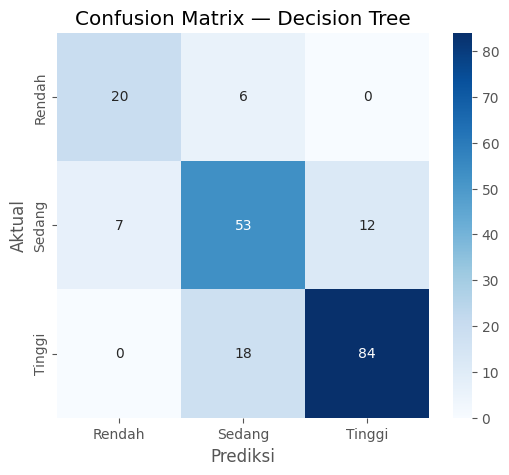

In [ ]:
# Confusion Matrix — Decision Tree
cm_dt = confusion_matrix_scratch(y_test, y_pred_dt, classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [ ]:
# Contoh hasil prediksi Decision Tree
hasil_dt = pd.DataFrame(X_test, columns=feature_names)
hasil_dt['Actual']  = y_test
hasil_dt['Prediksi'] = y_pred_dt

hasil_dt[['study_hours_per_day', 'sleep_hours', 'attendance_percentage', 'Actual', 'Prediksi']].head(5)

,study_hours_per_day,sleep_hours,attendance_percentage,Actual,Prediksi
0,4.8,6.4,92.7,Tinggi,Tinggi
1,2.1,6.9,70.9,Sedang,Sedang
2,3.2,6.9,100.0,Tinggi,Sedang
3,2.6,7.1,74.5,Rendah,Rendah
4,4.5,7.6,95.3,Tinggi,Tinggi


## 11. Evaluasi Naive Bayes

In [ ]:
print("=" * 55)
print("          LAPORAN KLASIFIKASI — NAIVE BAYES")
print("=" * 55)
classification_report_scratch(y_test, y_pred_nb, classes)
print(f"\nAccuracy: {accuracy(y_test, y_pred_nb):.4f}")

          LAPORAN KLASIFIKASI — NAIVE BAYES
Kelas         Precision     Recall   F1-Score    Support
-------------------------------------------------------
Rendah           0.7778     0.5385     0.6364         26
Sedang           0.6905     0.8056     0.7436         72
Tinggi           0.8980     0.8627     0.8800        102
-------------------------------------------------------
Weighted Avg     0.8076     0.8000     0.7992        200

Accuracy: 0.8000


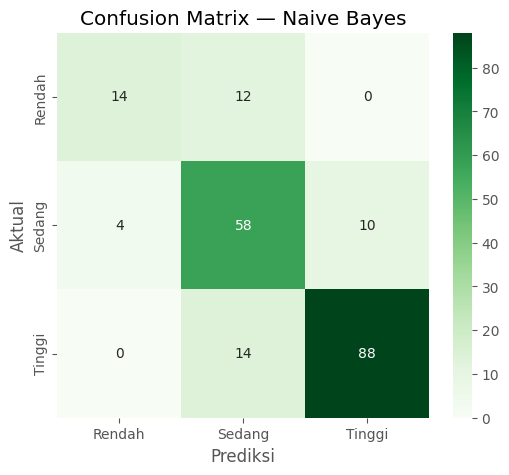

In [ ]:
# Confusion Matrix — Naive Bayes
cm_nb = confusion_matrix_scratch(y_test, y_pred_nb, classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix — Naive Bayes")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [ ]:
# Tampilkan probabilitas 5 data pertama (Naive Bayes)
print("Probabilitas Prediksi Naive Bayes — 5 Data Pertama\n")
for i in range(5):
    print(f"===== Data ke-{i+1} =====")
    print(f"P(Rendah | data) = {prob[i][0]:.4f}")
    print(f"P(Sedang  | data) = {prob[i][1]:.4f}")
    print(f"P(Tinggi  | data) = {prob[i][2]:.4f}")
    print(f"Prediksi          = {y_pred_nb[i]}")
    print("-" * 40)

Probabilitas Prediksi Naive Bayes — 5 Data Pertama

===== Data ke-1 =====
P(Rendah | data) = 0.0006
P(Sedang  | data) = 0.1499
P(Tinggi  | data) = 0.8495
Prediksi          = Tinggi
----------------------------------------
===== Data ke-2 =====
P(Rendah | data) = 0.2066
P(Sedang  | data) = 0.7115
P(Tinggi  | data) = 0.0819
Prediksi          = Sedang
----------------------------------------
===== Data ke-3 =====
P(Rendah | data) = 0.0082
P(Sedang  | data) = 0.2603
P(Tinggi  | data) = 0.7315
Prediksi          = Tinggi
----------------------------------------
===== Data ke-4 =====
P(Rendah | data) = 0.3888
P(Sedang  | data) = 0.5454
P(Tinggi  | data) = 0.0658
Prediksi          = Sedang
----------------------------------------
===== Data ke-5 =====
P(Rendah | data) = 0.0049
P(Sedang  | data) = 0.5452
P(Tinggi  | data) = 0.4499
Prediksi          = Sedang
----------------------------------------


## 12. Perbandingan Hasil Kedua Algoritma

In [ ]:
wp_dt, wr_dt, wf_dt, *_ = precision_recall_f1(y_test, y_pred_dt, classes)
wp_nb, wr_nb, wf_nb, *_ = precision_recall_f1(y_test, y_pred_nb, classes)

hasil = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Naive Bayes'],
    'Accuracy':  [accuracy(y_test, y_pred_dt),  accuracy(y_test, y_pred_nb)],
    'Precision': [wp_dt, wp_nb],
    'Recall':    [wr_dt, wr_nb],
    'F1-Score':  [wf_dt, wf_nb]
})

hasil.set_index('Algoritma').round(4)

,Accuracy,Precision,Recall,F1-Score
Algoritma,,,,
Decision Tree,0.785,0.7903,0.785,0.7869
Naive Bayes,0.800,0.8076,0.800,0.7992


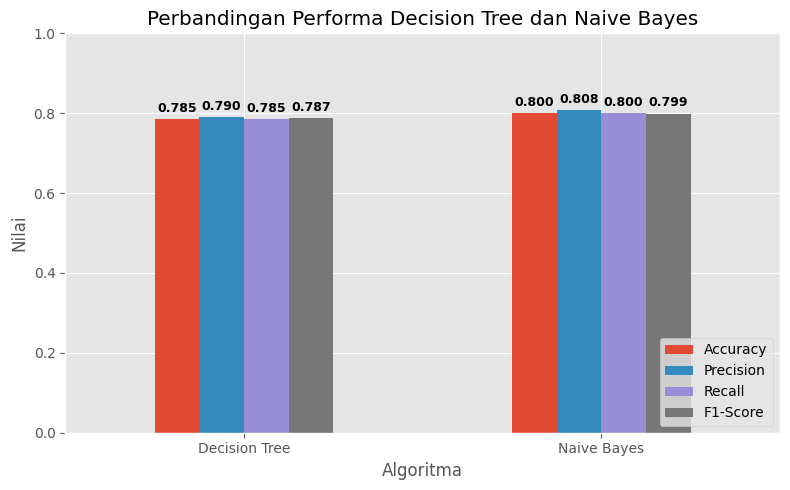

In [ ]:
# Visualisasi perbandingan semua metrik
ax = hasil.set_index('Algoritma').plot(kind='bar', figsize=(8, 5))
plt.ylabel('Nilai')
plt.title('Perbandingan Performa Decision Tree dan Naive Bayes')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

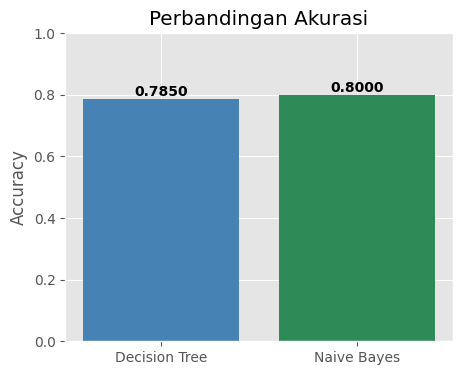

In [ ]:
# Visualisasi khusus Accuracy
plt.figure(figsize=(5, 4))
plt.bar(hasil['Algoritma'], hasil['Accuracy'], color=['steelblue', 'seagreen'])
plt.ylim(0, 1)
plt.title('Perbandingan Akurasi')
plt.ylabel('Accuracy')
for i, v in enumerate(hasil['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

In [ ]:
# ============================================================
# CEK OVERFITTING: Akurasi Training vs Testing (SCRATCH)
# ============================================================

# --- Decision Tree ---
y_pred_dt_train = np.array([predict_tree(dt_tree, x) for x in X_train])
train_acc_dt = accuracy(y_train, y_pred_dt_train)
test_acc_dt  = accuracy(y_test, y_pred_dt)

# --- Naive Bayes ---
y_pred_nb_train = nb.predict(X_train)
train_acc_nb = accuracy(y_train, y_pred_nb_train)
test_acc_nb  = accuracy(y_test, y_pred_nb)

print("=== Decision Tree (Scratch) ===")
print(f"Akurasi Training : {train_acc_dt:.4f} ({train_acc_dt*100:.2f}%)")
print(f"Akurasi Testing  : {test_acc_dt:.4f} ({test_acc_dt*100:.2f}%)")
print(f"Selisih (gap)    : {(train_acc_dt-test_acc_dt)*100:.2f}%")

print("\n=== Naive Bayes (Scratch) ===")
print(f"Akurasi Training : {train_acc_nb:.4f} ({train_acc_nb*100:.2f}%)")
print(f"Akurasi Testing  : {test_acc_nb:.4f} ({test_acc_nb*100:.2f}%)")
print(f"Selisih (gap)    : {(train_acc_nb-test_acc_nb)*100:.2f}%")

=== Decision Tree (Scratch) ===
Akurasi Training : 0.7887 (78.88%)
Akurasi Testing  : 0.7850 (78.50%)
Selisih (gap)    : 0.37%

=== Naive Bayes (Scratch) ===
Akurasi Training : 0.8087 (80.88%)
Akurasi Testing  : 0.8000 (80.00%)
Selisih (gap)    : 0.87%


In [ ]:
# ============================================================
# UJI DATA BARU (di luar dataset) — SCRATCH
# ============================================================

data_baru = pd.DataFrame([{
    'age': 20,
    'gender': 1,                        # 0=Female, 1=Male, 2=Other
    'study_hours_per_day': 5.5,
    'social_media_hours': 5.5,
    'netflix_hours': 8.5,
    'part_time_job': 0,                 # 0=No, 1=Yes
    'attendance_percentage': 92.0,
    'sleep_hours': 7.0,
    'diet_quality': 1,                  # 0=Fair, 1=Good, 2=Poor
    'exercise_frequency': 4,
    'parental_education_level': 2,      # 0=Bachelor, 1=High School, 2=Master
    'internet_quality': 1,              # 0=Average, 1=Good, 2=Poor
    'mental_health_rating': 4,
    'extracurricular_participation': 1  # 0=No, 1=Yes
}])

# Pastikan urutan kolom sama persis dengan feature_names saat training
data_baru = data_baru[feature_names]

# Ubah ke numpy array (karena predict_tree & nb.predict scratch pakai array, bukan DataFrame)
data_baru_arr = data_baru.values

# --- Decision Tree (Scratch) ---
pred_dt = predict_tree(dt_tree, data_baru_arr[0])

# --- Naive Bayes (Scratch) ---
pred_nb = nb.predict(data_baru_arr)

print("Prediksi Decision Tree (Scratch):", pred_dt)
print("Prediksi Naive Bayes (Scratch)  :", pred_nb[0])

Prediksi Decision Tree (Scratch): Tinggi
Prediksi Naive Bayes (Scratch)  : Sedang


---
## Ringkasan

| Komponen | Versi Scratch (notebook ini) |
|---|---|
| Label Encoding | Dibuat manual dengan mapping dictionary |
| Train-Test Split | Dibuat manual dengan stratifikasi per kelas |
| Decision Tree | Dibuat dari fungsi `gini_impurity`, `best_split`, `build_tree`, `predict_tree` |
| Naive Bayes | Dibuat sebagai class `GaussianNaiveBayes` dengan `fit`, `predict_proba`, `predict` |
| Evaluasi | Accuracy, Confusion Matrix, Precision, Recall, F1 — semua dari nol |

> ✅ Tidak ada fungsi dari `sklearn` yang digunakan dalam proses modeling dan evaluasi.